In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and preview data

In [2]:
df = pd.read_csv("/home/moraa-ontita/Documents/Machine-learning/talent_survey/data/Louisville_Metro_KY_-_Open_Data_Data_Set_Inventory_Updated_for_2019.csv")

In [3]:
df.head()

,ObjectId,Data_Set_Name,Brief_Description_of_Data,Data_Source,Home_Department,Home_Department_Division,Data_Steward__Business__Name,Data_Custodian__Technical__Name,Data_Classification,Data_Format,Frequency_of_Data_Change,Time_Span,Start_Date,End_Date,Geographic_Coverage,Geographic_Granularity,Link_to_Existing_Publication
0,1,Meter,"Meter Information, location type, rates etc\n\n",Meter Bagging,Parking Authority of River City,NaN,NaN,NaN,Public,Access Consolidated Database,Continuous,NaN,NaN,NaN,Citywide,Not applicable,NaN
1,2,Property Maintenance Cases,NaN,Hansen 8,Codes & Regulations,Property Maintenance Division,Benjamin Anderson,NaN,Public,csv file,Not updated (historical only),5 Years,NaN,NaN,Citywide,Latitude/longitude;#Street address,https://data.louisvilleky.gov/dataset/property...
2,3,Order Meter,Data on orders with meter information\n\n,Meter Bagging,Parking Authority of River City,NaN,NaN,NaN,Public,Access Consolidated Database,Continuous,2007-,NaN,NaN,Citywide,Not applicable,NaN
3,4,Meter Order Summary,​Order centric data for Meter Bagging\n,NaN,Parking Authority of River City,On Street,NaN,NaN,Public,Unknown,Continuous,2007-,NaN,NaN,Citywide,Not applicable,NaN
4,5,Passport Transaction Detail,NaN,Passport (GO502),Parking Authority of River City,NaN,NaN,NaN,Internal,Excel Spread Sheets,Continuous,NaN,NaN,NaN,Citywide,Not applicable,NaN


In [5]:
df.shape

(143, 17)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   ObjectId                         143 non-null    int64 
 1   Data_Set_Name                    143 non-null    object
 2   Brief_Description_of_Data        132 non-null    object
 3   Data_Source                      128 non-null    object
 4   Home_Department                  143 non-null    object
 5   Home_Department_Division         117 non-null    object
 6   Data_Steward__Business__Name     125 non-null    object
 7   Data_Custodian__Technical__Name  96 non-null     object
 8   Data_Classification              143 non-null    object
 9   Data_Format                      143 non-null    object
 10  Frequency_of_Data_Change         143 non-null    object
 11  Time_Span                        73 non-null     object
 12  Start_Date                       37 

# Checking for missing Values

In [7]:
# Count missing values per column
missing_values = df.isnull().sum()

# Filter columns with missing values
missing_values_filtered = missing_values[missing_values > 0]

# Display the result
print("Columns with missing values:\n")
print(missing_values_filtered)

# Total number of such columns
print(f"\nNumber of columns with missing values: {missing_values_filtered.shape[0]}")

# Total number of missing values across the dataset
print(f"Total missing values in the dataset: {missing_values_filtered.sum()}")


Columns with missing values:

Brief_Description_of_Data           11
Data_Source                         15
Home_Department_Division            26
Data_Steward__Business__Name        18
Data_Custodian__Technical__Name     47
Time_Span                           70
Start_Date                         106
End_Date                           141
Link_to_Existing_Publication        76
dtype: int64

Number of columns with missing values: 9
Total missing values in the dataset: 510


In [8]:
# Count missing values per column
missing_values = df.isnull().sum()

# Calculate percentage of missing values per column
missing_percent = (missing_values / len(df)) * 100

# Filter columns with more than 40% missing values
high_missing = missing_percent[missing_percent > 40]

# Display the result
print("Columns with more than 40% missing data:\n")
print(high_missing.sort_values(ascending=False))

# Total number of such columns
print(f"\nNumber of columns with >40% missing values: {high_missing.shape[0]}")


Columns with more than 40% missing data:

End_Date                        98.601399
Start_Date                      74.125874
Link_to_Existing_Publication    53.146853
Time_Span                       48.951049
dtype: float64

Number of columns with >40% missing values: 4


In [10]:
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [ObjectId, Data_Set_Name, Brief_Description_of_Data, Data_Source, Home_Department, Home_Department_Division, Data_Steward__Business__Name, Data_Custodian__Technical__Name, Data_Classification, Data_Format, Frequency_of_Data_Change, Time_Span, Start_Date, End_Date, Geographic_Coverage, Geographic_Granularity, Link_to_Existing_Publication]
Index: []


In [11]:
df.describe(include='all')

,ObjectId,Data_Set_Name,Brief_Description_of_Data,Data_Source,Home_Department,Home_Department_Division,Data_Steward__Business__Name,Data_Custodian__Technical__Name,Data_Classification,Data_Format,Frequency_of_Data_Change,Time_Span,Start_Date,End_Date,Geographic_Coverage,Geographic_Granularity,Link_to_Existing_Publication
count,143.00000,143,132,128,143,117,125,96,143,143,143,73,37,2,143,143,67
unique,NaN,143,132,30,20,45,63,39,3,21,9,40,24,2,4,19,38
top,NaN,Meter,"Meter Information, location type, rates etc\n\n",EHMIS-Environmental Health Management Informat...,Public Health & Wellness,Environmental Services,Kelly Monahan,Gerald Kaforski,Public,csv file,Continuous,Daily,1/1/2010,3/19/2018,Citywide,Not applicable,https://data.louisvilleky.gov/dataset/environm...
freq,NaN,1,1,23,27,23,23,26,91,46,63,9,7,1,118,50,9
mean,72.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,41.42463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,36.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,72.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,107.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.head()

,ObjectId,Data_Set_Name,Brief_Description_of_Data,Data_Source,Home_Department,Home_Department_Division,Data_Steward__Business__Name,Data_Custodian__Technical__Name,Data_Classification,Data_Format,Frequency_of_Data_Change,Time_Span,Start_Date,End_Date,Geographic_Coverage,Geographic_Granularity,Link_to_Existing_Publication
0,1,Meter,"Meter Information, location type, rates etc\n\n",Meter Bagging,Parking Authority of River City,NaN,NaN,NaN,Public,Access Consolidated Database,Continuous,NaN,NaN,NaN,Citywide,Not applicable,NaN
1,2,Property Maintenance Cases,NaN,Hansen 8,Codes & Regulations,Property Maintenance Division,Benjamin Anderson,NaN,Public,csv file,Not updated (historical only),5 Years,NaN,NaN,Citywide,Latitude/longitude;#Street address,https://data.louisvilleky.gov/dataset/property...
2,3,Order Meter,Data on orders with meter information\n\n,Meter Bagging,Parking Authority of River City,NaN,NaN,NaN,Public,Access Consolidated Database,Continuous,2007-,NaN,NaN,Citywide,Not applicable,NaN
3,4,Meter Order Summary,​Order centric data for Meter Bagging\n,NaN,Parking Authority of River City,On Street,NaN,NaN,Public,Unknown,Continuous,2007-,NaN,NaN,Citywide,Not applicable,NaN
4,5,Passport Transaction Detail,NaN,Passport (GO502),Parking Authority of River City,NaN,NaN,NaN,Internal,Excel Spread Sheets,Continuous,NaN,NaN,NaN,Citywide,Not applicable,NaN


In [15]:
df['Data_Set_Name'].value_counts()

Data_Set_Name
Meter                                        1
Property Maintenance Cases                   1
Order Meter                                  1
Meter Order Summary                          1
Passport Transaction Detail                  1
                                            ..
Work Order Archives                          1
Locations                                    1
Registered Businesses of Jefferson County    1
Parking Citations                            1
Meter Bagging Order Transaction Detail       1
Name: count, Length: 143, dtype: int64

In [ ]:
df['Data_Source'].value_counts()

Data_Source
EHMIS-Environmental Health Management Information System    23
Hansen 8                                                    17
Excel Spreadsheet                                           16
LOJIC                                                       15
Sharepoint                                                  11
APCD Emissions Inventory System                              5
PeopleSoft Reader                                            5
Data Governance Member Participation                         4
Syringe Exchange Program Data                                3
Overdoses                                                    3
Waze for Cities                                              3
Meter Bagging                                                3
Accela                                                       2
Oracle Financials (LEAP)                                     2
Hansen                                                       1
Centracs                                   

In [ ]:
df['Home_Department'].value_counts()

Home_Department
Public Health & Wellness             27
PW&A - Solid Waste Mgmt Srvs         18
Develop Louisville                   18
PW&A - Streets and Roads             18
Econ Growth & Innovation-APCD        12
Parking Authority of River City      10
Codes & Regulations                   7
Metro Technology Services             7
Office of Performance Improvement     7
Metro Police                          3
Louisville Metro EMS                  3
Emergency Mgt Agency/MetroSafe        2
OMB - Fleet & Facilities              2
OMB - Finance                         2
Kentuckiana Works Foundation          2
Human Resources                       1
Library                               1
Internal Auditor                      1
Metro Animal Services                 1
OMB - Revenue Commission              1
Name: count, dtype: int64

In [ ]:
df['Data_Classification'].value_counts()

Data_Classification
Public       91
Internal     43
Sensitive     9
Name: count, dtype: int64

In [19]:
df['Geographic_Coverage'].value_counts()

Geographic_Coverage
Citywide          118
Other              15
Subset of city      8
Regional            2
Name: count, dtype: int64

# Analyzing Missing Values

## 1. Calculate missingness across time-related columns:

In [20]:
time_cols = ["Start_Date", "End_Date", "Time_Span"]
missing_time_info = df[time_cols].isnull().mean() * 100
print("Percentage of missing values:\n", missing_time_info)


Percentage of missing values:
 Start_Date    74.125874
End_Date      98.601399
Time_Span     48.951049
dtype: float64


## 2. Group by department to see who’s most/least transparent

In [28]:
# Count total missing values per row (i.e., per dataset)
df["Missing_Fields_Count"] = df.isnull().sum(axis=1)

# Group by department and calculate average missing fields per dataset
dept_missing = (
    df.groupby("Home_Department")["Missing_Fields_Count"]
    .mean()
    .sort_values(ascending=False)
)

# Display top 10 departments with the highest average missing fields
print(dept_missing.head(10))


Home_Department
Metro Police                       6.333333
Kentuckiana Works Foundation       6.000000
Parking Authority of River City    6.000000
Library                            5.000000
Codes & Regulations                4.285714
Human Resources                    4.000000
Internal Auditor                   4.000000
Metro Animal Services              4.000000
Develop Louisville                 3.777778
PW&A - Solid Waste Mgmt Srvs       3.777778
Name: Missing_Fields_Count, dtype: float64


/tmp/ipykernel_857191/105480838.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_missing.head(10).values, y=dept_missing.head(10).index, palette="Reds_r")


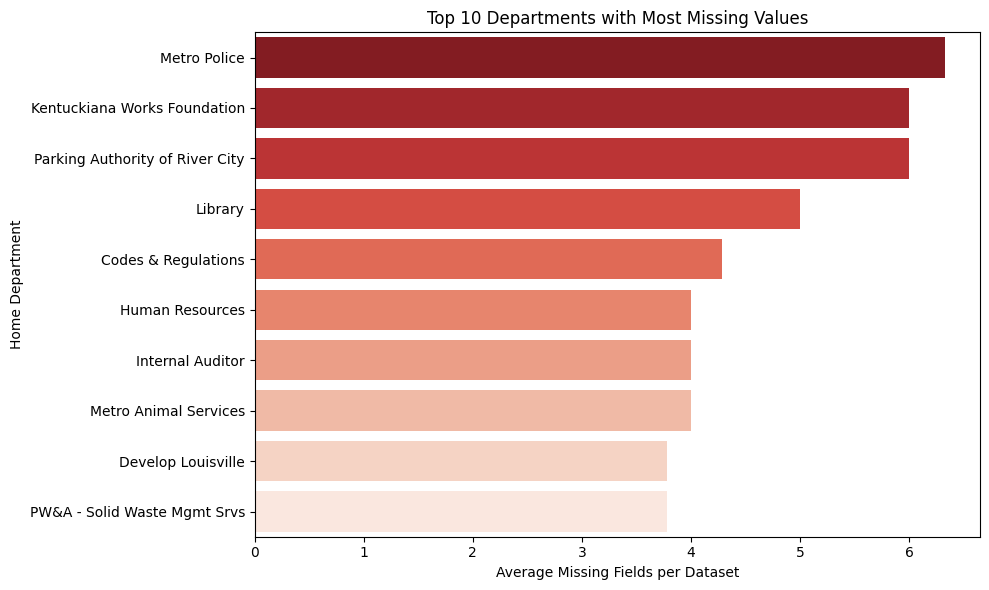

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x=dept_missing.head(10).values, y=dept_missing.head(10).index, palette="Reds_r")
plt.xlabel("Average Missing Fields per Dataset")
plt.ylabel("Home Department")
plt.title("Top 10 Departments with Most Missing Values")
plt.tight_layout()
plt.show()


# Insights

## 1. High Overall Missingness in Datasets
The analysis shows that missing data is prevalent across all departments, with a substantial variation in the number of missing fields per row.

Metro Police has the highest average of missing fields per row, with approximately 6.33 missing fields.

Kentuckiana Works Foundation and Parking Authority of River City follow with an average of 6.00 missing fields each.

Other departments such as Library (5.00 missing fields), Codes & Regulations (4.29 missing fields), and Human Resources (4.00 missing fields) also show significant gaps in data completeness.

This widespread missingness across row indicates that data quality might not be prioritized consistently across departments, making it difficult to fully assess the status of various civic services.

## 2. Departmental Differences in Data Completeness
The frequency of missing data varies significantly by department, with Metro Police, Kentuckiana Works Foundation, and Parking Authority of River City showing the highest average number of missing fields per row.

Metro Police has the largest gap in data completeness, averaging over 6 missing fields per row.

Departments like Library, Codes & Regulations, and Human Resources have slightly lower missing field averages, but still show noticeable gaps.

Public Health & Wellness and Metro Animal Services, while not having the highest averages, also contribute to the overall inconsistency in data completeness.

The variability in missing data suggests that the data management practices across different departments may vary, with some agencies performing better in ensuring complete records than others. However, no department is entirely free from missing data, pointing to systemic challenges in ensuring comprehensive data collection and maintenance.

## 3. Impact on Civic Technology Goals
The gaps in data completeness, particularly regarding missing fields across rows, create challenges for effective transparency, citizen engagement, and public service delivery.

Without a clear and complete picture of what data is available, it's challenging to foster government transparency, encourage citizen participation, or assess public service effectiveness. These data gaps, though not as extreme as those in temporal fields, still need addressing to create a more accessible and accountable public sector.

## Civic Technology Recommendations
**Develop a Data Completeness Dashboard**

Implement a civic tech dashboard that tracks and displays the completeness of datasets by department. This transparency tool would provide an easy way for the public and government employees to monitor progress in improving data quality. It could also be used to highlight areas where data is consistently missing.

**Establish Data Quality Standards**

Advocate for the implementation of clear data standards across all departments, requiring datasets to meet certain completeness thresholds. Departments with higher averages of missing fields could be flagged for additional scrutiny or support. Standardization of data quality can help improve consistency across agencies.

**Promote Automated Data Monitoring**

Build tools that automatically monitor dataset completeness and alert departments when critical fields are missing. These tools could serve as real-time alerts for departments to update datasets, reducing the reliance on manual audits and encouraging proactive data management.

**Targeted Training Programs for Departments**

Offer specialized training to departments with the highest rates of missing fields, such as Metro Police and Kentuckiana Works Foundation. By providing tailored support, such as templates, better data entry tools, or user-friendly interfaces, departments can improve their data collection practices. Civic tech tools could also integrate auto-fill features to assist staff in populating missing data fields.

